# GDV final analysis: attack patterns from the 2022 FIFA World Cup

This notebook creates the final data tables and figures for the GDV report.

The main question is:

**Which simple attacking patterns from the 2022 FIFA World Cup can amateur coaches use as training ideas?**

I focus on regular shot sequences. Penalty shootouts, penalties and direct free kick shots are removed because they do not describe normal build up play. Corners and throw ins stay in the data because they can still continue as regular attacking sequences.

The notebook follows this order:

1. quick data check
2. data preparation
3. final visualizations
4. short evaluation link
5. final notebook check

## 1. Setup

I load the packages, create the folders and define the basic plot settings.

In [1]:
from pathlib import Path
import ast
import math
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
warnings.filterwarnings('ignore')
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == 'GDV':
    PROJECT_ROOT = PROJECT_ROOT.parent
GDV_DIR = PROJECT_ROOT / 'GDV'
DATA_DIR = GDV_DIR / 'data'
FIGURE_DIR = GDV_DIR / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
COMPETITION_ID = 43
SEASON_ID = 106
SHOT_SEQUENCES_FILE = DATA_DIR / 'gdv_shot_sequences.csv'
ENTRY_POSSESSIONS_FILE = DATA_DIR / 'gdv_final_third_entries.csv'
TEAM_SUMMARY_FILE = DATA_DIR / 'gdv_team_attack_summary.csv'
EXCLUDED_SHOT_CONTEXTS = {'Penalty shootout', 'Penalty', 'Free kick'}
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color'] = '#222222'
plt.rcParams['ytick.color'] = '#222222'
plt.rcParams['font.size'] = 10
COLORS = {'direct': '#2F6B9A', 'medium2': '#E69F00', 'medium': '#66A61E', 'long': '#7570B3', 'shot': '#4C78A8', 'goal': '#E45756', 'grey': '#D9D9D9', 'dark': '#222222'}
print('Project folder:', PROJECT_ROOT)


C:\Users\tezca\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tezca\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Project folder: c:\Users\tezca\Football


## 2. Quick data check

Before creating the final plots, I first check the structure of the StatsBomb data.

This short EDA uses only a small sample of matches. The goal is not to analyse the whole tournament here, but to understand which event types and columns are useful for the final GDV analysis.

In [2]:
competitions = sb.competitions()
world_cup_2022 = competitions[competitions['competition_name'].str.contains('FIFA World Cup', case=False, na=False) & competitions['season_name'].astype(str).str.contains('2022', case=False, na=False)].copy()
display(world_cup_2022[['competition_id', 'season_id', 'competition_name', 'season_name']])
COMPETITION_ID = int(world_cup_2022.iloc[0]['competition_id'])
SEASON_ID = int(world_cup_2022.iloc[0]['season_id'])
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
display(matches[['match_id', 'match_date', 'home_team', 'away_team', 'competition_stage']].head(10))
print('Number of matches:', len(matches))


,competition_id,season_id,competition_name,season_name
30,43,106,FIFA World Cup,2022


,match_id,match_date,home_team,away_team,competition_stage
0,3857276,2022-12-01,Canada,Morocco,Group Stage
1,3857271,2022-11-21,England,Iran,Group Stage
2,3857296,2022-12-01,Croatia,Belgium,Group Stage
3,3857274,2022-11-25,Netherlands,Ecuador,Group Stage
4,3857255,2022-12-01,Japan,Spain,Group Stage
5,3857272,2022-11-25,England,United States,Group Stage
6,3857278,2022-11-29,Iran,United States,Group Stage
7,3857277,2022-11-23,Morocco,Croatia,Group Stage
8,3857273,2022-11-25,Wales,Iran,Group Stage
9,3857275,2022-11-30,Tunisia,France,Group Stage


Number of matches: 64


### Match table

The match table gives the available World Cup matches and basic context such as teams, date and tournament stage.

For the final analysis, `match_id` is the key column because it is needed to load the event data.

In [3]:
sample_matches = matches.head(3).copy()
sample_events = []
for _, match in sample_matches.iterrows():
    events = sb.events(match_id=int(match['match_id']))
    events['match_id'] = int(match['match_id'])
    events['match_label'] = f"{match['home_team']} vs {match['away_team']}"
    sample_events.append(events)
eda_events = pd.concat(sample_events, ignore_index=True)
print('Sample shape:', eda_events.shape)
display(eda_events.head())


Sample shape: (11153, 106)


,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,...,foul_won_penalty,goalkeeper_body_part,goalkeeper_shot_saved_to_post,pass_cut_back,shot_deflected,shot_saved_to_post,ball_recovery_offensive,pass_no_touch,pass_straight,shot_redirect
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Event data sample

Each row in the event data is one football action, for example a pass, carry, shot or duel.

Many columns are only filled for specific event types. For example, shot columns are filled for shots and pass columns are filled for passes. This means missing values are expected.

In [4]:
columns_overview = pd.DataFrame({'column': eda_events.columns, 'missing_share': eda_events.isna().mean().values}).sort_values('missing_share', ascending=False)
display(columns_overview.head(20))
display(columns_overview.tail(20))


,column,missing_share
105,shot_redirect,0.999910
101,shot_saved_to_post,0.999910
76,shot_open_goal,0.999910
94,foul_committed_penalty,0.999910
98,goalkeeper_shot_saved_to_post,0.999910
96,foul_won_penalty,0.999910
102,ball_recovery_offensive,0.999910
104,pass_straight,0.999910
30,injury_stoppage_in_chain,0.999821
49,pass_miscommunication,0.999821


,column,missing_share
67,related_events,0.036851
32,location,0.007980
63,position,0.004393
62,player_id,0.004393
61,player,0.004393
29,index,0.000000
91,match_label,0.000000
89,type,0.000000
88,timestamp,0.000000
87,team_id,0.000000


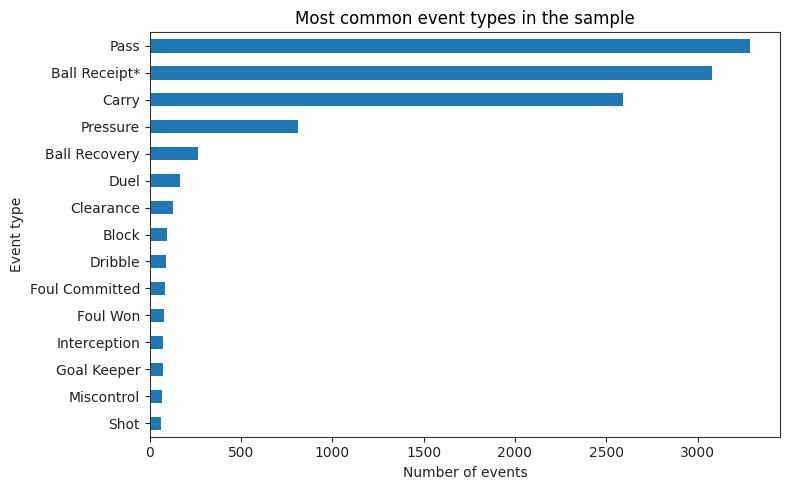

In [ ]:
event_type_counts = eda_events['type'].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))

event_type_counts.plot(kind='barh', ax=ax)

ax.set_title('Most common event types in the sample')
ax.set_xlabel('Number of events')
ax.set_ylabel('Event type')

plt.tight_layout()

plt.show()



### Relevant event types

I do not use every event type.

For this project, the important parts are shots, passes, carries, locations and possessions. These are enough to describe simple attacking patterns before a shot.

Defensive events and goalkeeper actions are not used because they are not central to the research question.

In [ ]:
eda_shots = eda_events[eda_events['type'].eq('Shot')].copy()
eda_passes = eda_events[eda_events['type'].eq('Pass')].copy()
eda_carries = eda_events[eda_events['type'].eq('Carry')].copy()

print('Shots:', len(eda_shots))
print('Passes:', len(eda_passes))
print('Carries:', len(eda_carries))

shot_cols = [col for col in ['match_label', 'minute', 'team', 'player', 'shot_type', 'shot_outcome', 'shot_statsbomb_xg', 'play_pattern'] if col in eda_shots.columns]
pass_cols = [col for col in ['match_label', 'minute', 'team', 'player', 'pass_outcome', 'location', 'pass_end_location'] if col in eda_passes.columns]
carry_cols = [col for col in ['match_label', 'minute', 'team', 'player', 'location', 'carry_end_location'] if col in eda_carries.columns]

display(eda_shots[shot_cols].head(8))
display(eda_passes[pass_cols].head(8))
display(eda_carries[carry_cols].head(8))


Shots: 60
Passes: 3287
Carries: 2594


,match_label,minute,team,player,shot_type,shot_outcome,shot_statsbomb_xg,play_pattern
3036,Canada vs Morocco,2,Canada,Mark Anthony Kaye,Open Play,Blocked,0.038882,Regular Play
3037,Canada vs Morocco,3,Morocco,Hakim Ziyech,Open Play,Goal,0.024477,From Throw In
3038,Canada vs Morocco,8,Morocco,Abdelhamid Sabiri,Free Kick,Blocked,0.022070,From Free Kick
3039,Canada vs Morocco,9,Morocco,Sofiane Boufal,Open Play,Wayward,0.061586,From Corner
3040,Canada vs Morocco,14,Canada,Tajon Buchanan,Open Play,Off T,0.279145,From Counter
3041,Canada vs Morocco,15,Morocco,Hakim Ziyech,Open Play,Off T,0.022624,From Goal Kick
3042,Canada vs Morocco,22,Morocco,Youssef En-Nesyri,Open Play,Goal,0.104058,From Throw In
3043,Canada vs Morocco,32,Morocco,Abdelhamid Sabiri,Open Play,Blocked,0.097118,Regular Play


,match_label,minute,team,player,pass_outcome,location,pass_end_location
6,Canada vs Morocco,0,Morocco,Youssef En-Nesyri,NaN,"[61.0, 40.1]","[48.5, 41.3]"
7,Canada vs Morocco,0,Morocco,Sofyan Amrabat,NaN,"[48.4, 42.5]","[30.5, 59.0]"
8,Canada vs Morocco,0,Morocco,Nayef Aguerd,NaN,"[30.9, 59.0]","[29.8, 26.9]"
9,Canada vs Morocco,0,Morocco,Romain Saïss,NaN,"[31.7, 26.2]","[24.8, 58.4]"
10,Canada vs Morocco,0,Morocco,Nayef Aguerd,NaN,"[26.9, 59.5]","[34.7, 78.0]"
11,Canada vs Morocco,0,Morocco,Achraf Hakimi Mouh,NaN,"[32.4, 79.2]","[36.8, 73.0]"
12,Canada vs Morocco,0,Morocco,Sofyan Amrabat,NaN,"[36.8, 73.0]","[43.5, 78.2]"
13,Canada vs Morocco,0,Morocco,Hakim Ziyech,NaN,"[37.3, 78.2]","[29.0, 79.6]"


,match_label,minute,team,player,location,carry_end_location
1829,Canada vs Morocco,0,Morocco,Sofyan Amrabat,"[48.5, 41.3]","[48.4, 42.5]"
1830,Canada vs Morocco,0,Morocco,Nayef Aguerd,"[30.5, 59.0]","[30.9, 59.0]"
1831,Canada vs Morocco,0,Morocco,Romain Saïss,"[29.8, 26.9]","[31.7, 26.2]"
1832,Canada vs Morocco,0,Morocco,Nayef Aguerd,"[24.8, 58.4]","[26.9, 59.5]"
1833,Canada vs Morocco,0,Morocco,Achraf Hakimi Mouh,"[34.7, 78.0]","[32.4, 79.2]"
1834,Canada vs Morocco,0,Morocco,Hakim Ziyech,"[43.5, 78.2]","[37.3, 78.2]"
1835,Canada vs Morocco,0,Morocco,Achraf Hakimi Mouh,"[29.0, 79.6]","[27.6, 78.0]"
1836,Canada vs Morocco,0,Morocco,Nayef Aguerd,"[14.1, 74.9]","[14.1, 74.4]"


shot_outcome
Off T            19
Blocked          14
Goal             10
Saved             8
Wayward           5
Post              3
Saved to Post     1
Name: count, dtype: int64

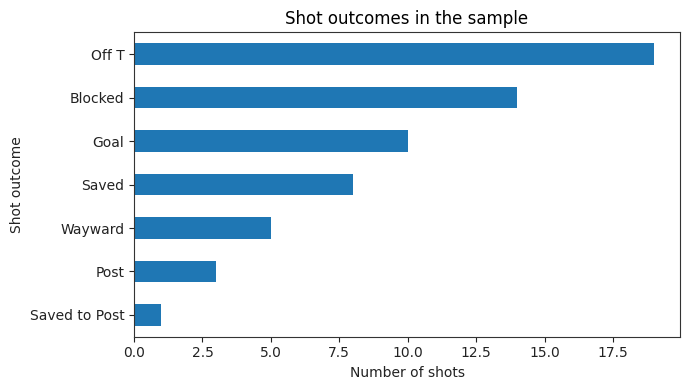

count    60.000000
mean      0.134028
std       0.171692
min       0.006141
25%       0.040701
50%       0.071026
75%       0.109104
max       0.783500
Name: shot_statsbomb_xg, dtype: float64

In [ ]:
if len(eda_shots) > 0:
    display(eda_shots['shot_outcome'].value_counts(dropna=False))

    fig, ax = plt.subplots(figsize=(7, 4))
    
    eda_shots['shot_outcome'].value_counts().sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Shot outcomes in the sample')
    ax.set_xlabel('Number of shots')
    ax.set_ylabel('Shot outcome')

    plt.tight_layout()
    plt.show()

    if 'shot_statsbomb_xg' in eda_shots.columns:

        display(eda_shots['shot_statsbomb_xg'].describe())


### Data decision: excluded shot situations

The final analysis uses regular attacking sequences only. Penalty shootouts, penalties and direct free kick shots are excluded because they do not describe normal build up play. Corners and throw ins stay in the data because they can still continue as regular attacking situations.

In [ ]:
special_shots = eda_shots.copy()

if 'shot_type' in special_shots.columns:
    display(special_shots['shot_type'].value_counts(dropna=False))

if 'play_pattern' in special_shots.columns:
    display(special_shots['play_pattern'].value_counts(dropna=False).head(10))

special_shots_view = special_shots[[col for col in ['match_label', 'minute', 'team', 'player', 'shot_type', 'shot_outcome', 'play_pattern', 'shot_statsbomb_xg'] if col in special_shots.columns]]

display(special_shots_view.head(15))


shot_type
Open Play    57
Free Kick     2
Penalty       1
Name: count, dtype: int64

play_pattern
Regular Play      17
From Corner       11
From Throw In     10
From Free Kick    10
From Goal Kick     4
From Counter       3
From Keeper        3
Other              1
From Kick Off      1
Name: count, dtype: int64

,match_label,minute,team,player,shot_type,shot_outcome,play_pattern,shot_statsbomb_xg
3036,Canada vs Morocco,2,Canada,Mark Anthony Kaye,Open Play,Blocked,Regular Play,0.038882
3037,Canada vs Morocco,3,Morocco,Hakim Ziyech,Open Play,Goal,From Throw In,0.024477
3038,Canada vs Morocco,8,Morocco,Abdelhamid Sabiri,Free Kick,Blocked,From Free Kick,0.022070
3039,Canada vs Morocco,9,Morocco,Sofiane Boufal,Open Play,Wayward,From Corner,0.061586
3040,Canada vs Morocco,14,Canada,Tajon Buchanan,Open Play,Off T,From Counter,0.279145
3041,Canada vs Morocco,15,Morocco,Hakim Ziyech,Open Play,Off T,From Goal Kick,0.022624
3042,Canada vs Morocco,22,Morocco,Youssef En-Nesyri,Open Play,Goal,From Throw In,0.104058
3043,Canada vs Morocco,32,Morocco,Abdelhamid Sabiri,Open Play,Blocked,Regular Play,0.097118
3044,Canada vs Morocco,47,Morocco,Youssef En-Nesyri,Open Play,Wayward,From Free Kick,0.094470
3045,Canada vs Morocco,57,Canada,Alphonso Davies,Open Play,Off T,Regular Play,0.051904


### Variables used later

After the first data check, I focus on the variables below.

| Variable | Why it is useful |
| --- | --- |
| `shot_outcome` | identifies goals and other shot outcomes |
| `shot_statsbomb_xg` | gives a simple measure of chance quality |
| `pass_outcome` | helps count completed passes |
| `location` | gives start positions on the pitch |
| `pass_end_location` | helps identify passes into the final third |
| `carry_end_location` | helps identify carries into the final third |
| `possession` | connects actions before a shot |
| `team` | allows team comparisons |
| `match_id` | connects events to matches |

Based on this check, I focus the final analysis on regular shots, build up length, final third entries and chance quality.

## 3. Helper functions

The helper functions turn the raw event data into measures that are easier to analyse.

The most important measures are completed passes before a shot, start zone, final third entry, entry method and shot outcome.

In [ ]:
def parse_location(value):
    if isinstance(value, list) and len(value) >= 2:
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) >= 2:
                return parsed
        except Exception:
            return None
    return None

def get_x(value):
    loc = parse_location(value)
    return loc[0] if isinstance(loc, list) else np.nan

def get_y(value):
    loc = parse_location(value)
    return loc[1] if isinstance(loc, list) else np.nan

def event_seconds(row):
    minute = 0 if pd.isna(row.get('minute')) else int(row.get('minute'))
    second = 0 if pd.isna(row.get('second')) else int(row.get('second'))
    return minute * 60 + second

def pass_category(n):
    if pd.isna(n):
        return np.nan
    n = int(n)
    if n <= 3:
        return '0-3'
    if n <= 6:
        return '4-6'
    if n <= 9:
        return '7-9'
    return '10+'

PASS_CATEGORY_ORDER = ['0-3', '4-6', '7-9', '10+']
PASS_CATEGORY_COLORS = {'0-3': COLORS['direct'], '4-6': COLORS['medium'], '7-9': COLORS['long'], '10+': '#6B7280'}

def start_zone(x):
    if pd.isna(x):
        return 'Unknown'
    if x < 40:
        return 'Defensive third'
    if x < 80:
        return 'Middle third'
    return 'Final third'

def is_completed_pass(row):
    if row.get('type') != 'Pass':
        return False
    outcome = row.get('pass_outcome')
    return pd.isna(outcome) or str(outcome).lower() in ['nan', 'none', '']

def pass_distance(row):
    if pd.isna(row.get('x')) or pd.isna(row.get('y')) or pd.isna(row.get('end_x')) or pd.isna(row.get('end_y')):
        return np.nan
    return float(np.sqrt((row.get('end_x') - row.get('x')) ** 2 + (row.get('end_y') - row.get('y')) ** 2))

def entry_method(row):
    if row is None:
        return 'No entry found'
    if row.get('type') in ['Carry', 'Carry/Dribbling']:
        return 'Carry'
    if row.get('type') == 'Pass':
        dist = pass_distance(row)
        if not pd.isna(dist) and dist >= 30:
            return 'Long pass'
        return 'Short pass'
    return 'Other'

def extract_formation(value):
    if isinstance(value, dict):
        return value.get('formation')
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, dict):
                return parsed.get('formation')
        except Exception:
            return np.nan
    return np.nan

def clean_label(value):
    if pd.isna(value):
        return ''
    return str(value).strip()

def contains_label(value, pattern):
    return pattern.lower() in clean_label(value).lower()

def shot_context(row):
    if int(row.get('period', 0) if not pd.isna(row.get('period', 0)) else 0) == 5:
        return 'Penalty shootout'
    shot_type = clean_label(row.get('shot_type'))
    play_pattern = clean_label(row.get('play_pattern'))
    if 'Penalty' in shot_type:
        return 'Penalty'
    if 'Free Kick' in shot_type or 'Free Kick' in play_pattern:
        return 'Free kick'
    if 'Corner' in play_pattern:
        return 'Corner'
    if 'Throw In' in play_pattern:
        return 'Throw in'
    return 'Open play / other'

def is_excluded_main_analysis_shot(row):
    if row.get('type') != 'Shot':
        return False
    return row.get('shot_context') in EXCLUDED_SHOT_CONTEXTS


## 4. Data preparation

The next cell contains the main preprocessing logic. I keep this part together so that the filtering and table creation stay consistent.

The important steps are:

1. prepare event locations and shot context
2. remove penalty shootouts, penalties and direct free kick shots from the main shot analysis
3. count completed passes before each regular shot
4. identify final third entries
5. create the final shot, entry and team summary tables

In [10]:
def prepare_events(events):
    needed_cols = [
        "id", "index", "period", "timestamp", "minute", "second",
        "team", "player", "type", "possession", "location",
        "pass_end_location", "carry_end_location", "pass_outcome",
        "shot_outcome", "shot_statsbomb_xg", "shot_type",
        "play_pattern", "tactics"
    ]

    for col in needed_cols:
        if col not in events.columns:
            events[col] = np.nan

    events = events.sort_values(["period", "index"]).copy()
    events["event_seconds"] = events.apply(event_seconds, axis=1)
    events["x"] = events["location"].apply(get_x)
    events["y"] = events["location"].apply(get_y)
    events["pass_end_x"] = events["pass_end_location"].apply(get_x)
    events["pass_end_y"] = events["pass_end_location"].apply(get_y)
    events["carry_end_x"] = events["carry_end_location"].apply(get_x)
    events["carry_end_y"] = events["carry_end_location"].apply(get_y)
    events["completed_pass"] = events.apply(is_completed_pass, axis=1)
    events["end_x"] = np.where(
        events["type"] == "Pass",
        events["pass_end_x"],
        events["carry_end_x"]
    )
    events["end_y"] = np.where(
        events["type"] == "Pass",
        events["pass_end_y"],
        events["carry_end_y"]
    )
    events["pass_distance"] = events.apply(pass_distance, axis=1)
    events["shot_context"] = events.apply(shot_context, axis=1)
    events["is_penalty_shootout"] = events["shot_context"].eq("Penalty shootout")
    events["is_standard_shot"] = events["shot_context"].isin(
        ["Penalty", "Free kick", "Corner", "Throw in"]
    )
    events["is_excluded_main_analysis_shot"] = events.apply(
        is_excluded_main_analysis_shot,
        axis=1
    )

    return events

def first_final_third_entry(group):
    candidates = group[
        group["type"].isin(["Pass", "Carry", "Carry/Dribbling"])
        & (group["x"] < 80)
        & (group["end_x"] >= 80)
    ].copy()

    candidates = candidates[
        (candidates["type"] != "Pass")
        | candidates["completed_pass"]
    ]

    if candidates.empty:
        return None

    return candidates.sort_values("index").iloc[0]

def build_analysis_tables(force_rebuild=False):
    cached_files_exist = (
        SHOT_SEQUENCES_FILE.exists()
        and ENTRY_POSSESSIONS_FILE.exists()
        and TEAM_SUMMARY_FILE.exists()
    )

    if cached_files_exist and not force_rebuild:
        shots = pd.read_csv(SHOT_SEQUENCES_FILE)
        entries = pd.read_csv(ENTRY_POSSESSIONS_FILE)
        team_summary = pd.read_csv(TEAM_SUMMARY_FILE)

        required_cols = {
            "period",
            "shot_type",
            "shot_context",
            "is_penalty_shootout",
            "is_excluded_main_analysis_shot"
        }

        if required_cols.issubset(set(shots.columns)):
            excluded = (
                shots["is_excluded_main_analysis_shot"]
                .astype(str)
                .str.lower()
            )
            shots = shots[~excluded.isin(["true", "1", "yes"])].copy()
            return shots, entries, team_summary

        print("Cached files use an older schema. Rebuilding analysis tables.")

    matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)

    shot_rows = []
    entry_rows = []
    formation_rows = []

    for match_nr, match in matches.reset_index(drop=True).iterrows():
        match_id = int(match["match_id"])
        match_label = f"{match['home_team']} vs {match['away_team']}"

        print(f"{match_nr + 1}/{len(matches)} {match_label}")

        try:
            events = sb.events(match_id=match_id)
        except Exception as exc:
            print("Could not load match", match_id, exc)
            continue

        events = prepare_events(events)
        events = events[~events["is_penalty_shootout"]].copy()

        starting_xi = events[events["type"] == "Starting XI"].copy()

        for _, row in starting_xi.iterrows():
            formation_rows.append(
                {
                    "match_id": match_id,
                    "team": row.get("team"),
                    "formation": extract_formation(row.get("tactics"))
                }
            )

        formation_map = {
            (item["match_id"], item["team"]): item["formation"]
            for item in formation_rows
        }

        for (team, possession), group in events.groupby(
            ["team", "possession"],
            dropna=True
        ):
            if pd.isna(team) or pd.isna(possession):
                continue

            group = group.sort_values("index").copy()
            located = group.dropna(subset=["x", "y"])

            if located.empty:
                continue

            start_event = located.iloc[0]
            entry = first_final_third_entry(group)
            already_final_third = start_event["x"] >= 80

            if entry is not None:
                entry_index = entry["index"]
                entry_seconds = entry["event_seconds"]
                entry_x = entry["x"]
                entry_y = entry["y"]
                entry_end_x = entry["end_x"]
                entry_end_y = entry["end_y"]
                method = entry_method(entry)

                before_entry = group[group["index"] <= entry_index]
                passes_to_entry = int(before_entry["completed_pass"].sum())
                time_to_entry = float(entry_seconds - start_event["event_seconds"])

            elif already_final_third:
                entry_index = start_event["index"]
                entry_seconds = start_event["event_seconds"]
                entry_x = start_event["x"]
                entry_y = start_event["y"]
                entry_end_x = start_event["x"]
                entry_end_y = start_event["y"]
                method = "Already in final third"
                passes_to_entry = 0
                time_to_entry = 0.0

            else:
                continue

            after_entry = group[group["index"] >= entry_index]
            shots_after_entry = after_entry[
                (after_entry["type"] == "Shot")
                & ~after_entry["is_excluded_main_analysis_shot"]
            ].copy()

            goals_after_entry = shots_after_entry[
                shots_after_entry["shot_outcome"]
                .astype(str)
                .str.lower()
                .eq("goal")
            ]

            involved_players = (
                group[group["index"] <= entry_index]["player"]
                .dropna()
                .nunique()
            )

            entry_rows.append(
                {
                    "match_id": match_id,
                    "match_label": match_label,
                    "team": team,
                    "possession": possession,
                    "formation": formation_map.get((match_id, team), np.nan),
                    "start_x": start_event["x"],
                    "start_y": start_event["y"],
                    "start_zone": start_zone(start_event["x"]),
                    "entry_x": entry_x,
                    "entry_y": entry_y,
                    "entry_end_x": entry_end_x,
                    "entry_end_y": entry_end_y,
                    "entry_method": method,
                    "passes_to_entry": passes_to_entry,
                    "time_to_entry": time_to_entry,
                    "fast_entry": bool(
                        passes_to_entry <= 5
                        and time_to_entry <= 15
                    ),
                    "players_before_entry": involved_players,
                    "shot_after_entry": int(len(shots_after_entry) > 0),
                    "goal_after_entry": int(len(goals_after_entry) > 0),
                    "shot_count_after_entry": int(len(shots_after_entry)),
                    "goal_count_after_entry": int(len(goals_after_entry)),
                    "max_xg_after_entry": (
                        shots_after_entry["shot_statsbomb_xg"].max()
                        if len(shots_after_entry)
                        else 0
                    ),
                    "xg_after_entry": (
                        shots_after_entry["shot_statsbomb_xg"].sum()
                        if len(shots_after_entry)
                        else 0
                    )
                }
            )

        shots = events[
            (events["type"] == "Shot")
            & ~events["is_excluded_main_analysis_shot"]
        ].copy()

        for _, shot in shots.iterrows():
            team = shot.get("team")
            possession = shot.get("possession")
            shot_index = shot.get("index")

            if pd.isna(team) or pd.isna(possession) or pd.isna(shot_index):
                continue

            build = events[
                (events["team"] == team)
                & (events["possession"] == possession)
                & (events["index"] <= shot_index)
            ].sort_values("index").copy()

            located = build.dropna(subset=["x", "y"])

            if located.empty:
                continue

            first_event = located.iloc[0]
            completed_passes = build[build["completed_pass"]]
            players_involved = build["player"].dropna().nunique()
            entry = first_final_third_entry(build)

            if entry is not None:
                before_entry = build[build["index"] <= entry["index"]]
                entry_method_value = entry_method(entry)
                passes_to_entry = int(before_entry["completed_pass"].sum())
                time_to_entry = float(
                    entry["event_seconds"] - first_event["event_seconds"]
                )

            elif first_event["x"] >= 80:
                entry_method_value = "Already in final third"
                passes_to_entry = 0
                time_to_entry = 0.0

            else:
                entry_method_value = "No entry found"
                passes_to_entry = np.nan
                time_to_entry = np.nan

            pass_count = int(len(completed_passes))
            duration = float(shot["event_seconds"] - first_event["event_seconds"])
            is_goal = str(shot.get("shot_outcome")).lower() == "goal"

            shot_rows.append(
                {
                    "match_id": match_id,
                    "match_label": match_label,
                    "team": team,
                    "opponent": (
                        match["away_team"]
                        if team == match["home_team"]
                        else match["home_team"]
                    ),
                    "possession": possession,
                    "formation": formation_map.get((match_id, team), np.nan),
                    "player": shot.get("player"),
                    "period": shot.get("period"),
                    "minute": shot.get("minute"),
                    "second": shot.get("second"),
                    "shot_type": shot.get("shot_type"),
                    "shot_context": shot.get("shot_context"),
                    "is_penalty_shootout": bool(
                        shot.get("is_penalty_shootout", False)
                    ),
                    "is_standard_shot": bool(
                        shot.get("is_standard_shot", False)
                    ),
                    "shot_outcome": shot.get("shot_outcome"),
                    "is_goal": int(is_goal),
                    "shot_xg": (
                        shot.get("shot_statsbomb_xg")
                        if not pd.isna(shot.get("shot_statsbomb_xg"))
                        else 0
                    ),
                    "play_pattern": shot.get("play_pattern"),
                    "passes_before_shot": pass_count,
                    "pass_category": pass_category(pass_count),
                    "duration_seconds": duration,
                    "players_involved": players_involved,
                    "start_x": first_event["x"],
                    "start_y": first_event["y"],
                    "start_zone": start_zone(first_event["x"]),
                    "shot_x": shot.get("x"),
                    "shot_y": shot.get("y"),
                    "entry_method": entry_method_value,
                    "passes_to_entry": passes_to_entry,
                    "time_to_entry": time_to_entry,
                    "fast_entry_before_shot": bool(
                        not pd.isna(passes_to_entry)
                        and passes_to_entry <= 5
                        and time_to_entry <= 15
                    )
                }
            )

        time.sleep(0.05)

    shots_df = pd.DataFrame(shot_rows)
    entries_df = pd.DataFrame(entry_rows)

    team_summary = (
        entries_df
        .groupby("team")
        .agg(
            entries=("team", "count"),
            fast_entries=("fast_entry", "sum"),
            shots_after_entry=("shot_after_entry", "sum"),
            goals_after_entry=("goal_after_entry", "sum"),
            avg_players_before_entry=("players_before_entry", "mean")
        )
        .reset_index()
    )

    team_summary["fast_entry_share"] = (
        team_summary["fast_entries"] / team_summary["entries"]
    )
    team_summary["shot_rate_after_entry"] = (
        team_summary["shots_after_entry"] / team_summary["entries"]
    )
    team_summary["goal_rate_after_entry"] = (
        team_summary["goals_after_entry"] / team_summary["entries"]
    )

    goal_summary = (
        shots_df[shots_df["is_goal"] == 1]
        .groupby("team")
        .agg(
            goals=("is_goal", "sum"),
            avg_passes_before_goal=("passes_before_shot", "mean"),
            avg_goal_duration=("duration_seconds", "mean")
        )
        .reset_index()
    )

    team_summary = (
        team_summary
        .merge(goal_summary, on="team", how="left")
        .fillna({"goals": 0})
    )

    shots_df.to_csv(SHOT_SEQUENCES_FILE, index=False)
    entries_df.to_csv(ENTRY_POSSESSIONS_FILE, index=False)
    team_summary.to_csv(TEAM_SUMMARY_FILE, index=False)

    return shots_df, entries_df, team_summary


In [11]:
shots_df, entries_df, team_summary = build_analysis_tables(force_rebuild=False)

if "is_excluded_main_analysis_shot" in shots_df.columns:
    excluded = shots_df["is_excluded_main_analysis_shot"].astype(str).str.lower()
    shots_df = shots_df[~excluded.isin(["true", "1", "yes"])].copy()
elif "shot_context" in shots_df.columns:
    shots_df = shots_df[~shots_df["shot_context"].isin(EXCLUDED_SHOT_CONTEXTS)].copy()

if "shot_context" not in shots_df.columns:
    shots_df["shot_context"] = "Not available in cached file"

shots_df["passes_before_shot"] = (
    pd.to_numeric(shots_df["passes_before_shot"], errors="coerce")
    .fillna(0)
    .astype(int)
)

shots_df["is_goal"] = (
    pd.to_numeric(shots_df["is_goal"], errors="coerce")
    .fillna(0)
    .astype(int)
)

shots_df["pass_category"] = shots_df["passes_before_shot"].apply(pass_category)
shots_df["pass_category"] = pd.Categorical(
    shots_df["pass_category"],
    categories=PASS_CATEGORY_ORDER,
    ordered=True
)

if "goal_after_entry" in entries_df.columns:
    entries_df["goal_after_entry"] = (
        pd.to_numeric(entries_df["goal_after_entry"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

if "shot_after_entry" in entries_df.columns:
    entries_df["shot_after_entry"] = (
        pd.to_numeric(entries_df["shot_after_entry"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

if shots_df.empty:
    raise ValueError("shots_df is empty. Run the notebook once with force_rebuild=True.")

if entries_df.empty:
    raise ValueError("entries_df is empty. Run the notebook once with force_rebuild=True.")

print("Regular shots:", len(shots_df))
print("Goals:", int(shots_df["is_goal"].sum()))
print("Final third entries:", len(entries_df))
print("Teams in shot data:", shots_df["team"].nunique())

display(shots_df.head())
display(entries_df.head())
display(team_summary.head())


Cached files use an older schema. Rebuilding analysis tables.
1/64 Canada vs Morocco
2/64 England vs Iran
3/64 Croatia vs Belgium
4/64 Netherlands vs Ecuador
5/64 Japan vs Spain
6/64 England vs United States
7/64 Iran vs United States
8/64 Morocco vs Croatia
9/64 Wales vs Iran
10/64 Tunisia vs France
11/64 Wales vs England
12/64 Switzerland vs Cameroon
13/64 Portugal vs Ghana
14/64 Senegal vs Netherlands
15/64 United States vs Wales
16/64 Poland vs Saudi Arabia
17/64 Netherlands vs Qatar
18/64 France vs Denmark
19/64 Germany vs Japan
20/64 Denmark vs Tunisia
21/64 Mexico vs Poland
22/64 Qatar vs Senegal
23/64 Belgium vs Canada
24/64 Brazil vs Switzerland
25/64 Netherlands vs Argentina
26/64 Costa Rica vs Germany
27/64 Japan vs Costa Rica
28/64 Argentina vs France
29/64 Croatia vs Morocco
30/64 Serbia vs Switzerland
31/64 Argentina vs Australia
32/64 Australia vs Denmark
33/64 Brazil vs Serbia
34/64 Tunisia vs Australia
35/64 Ecuador vs Senegal
36/64 Uruguay vs South Korea
37/64 Morocco

,match_id,match_label,team,opponent,possession,formation,player,period,minute,second,...,players_involved,start_x,start_y,start_zone,shot_x,shot_y,entry_method,passes_to_entry,time_to_entry,fast_entry_before_shot
0,3857276,Canada vs Morocco,Canada,Morocco,6,4411,Mark Anthony Kaye,1,2,5,...,4,69.3,13.7,Middle third,96.5,40.7,Short pass,2.0,3.0,True
1,3857276,Canada vs Morocco,Morocco,Canada,8,433,Hakim Ziyech,1,3,29,...,7,87.0,4.7,Final third,83.9,45.0,Already in final third,0.0,0.0,True
2,3857276,Canada vs Morocco,Morocco,Canada,17,433,Sofiane Boufal,1,9,9,...,2,120.0,80.0,Final third,107.0,48.3,Already in final third,0.0,0.0,True
3,3857276,Canada vs Morocco,Canada,Morocco,30,4411,Tajon Buchanan,1,14,7,...,4,16.1,69.7,Defensive third,113.3,34.9,Carry,3.0,8.0,True
4,3857276,Canada vs Morocco,Morocco,Canada,31,433,Hakim Ziyech,1,15,6,...,9,7.0,44.1,Defensive third,97.5,54.0,Carry,10.0,25.0,False


,match_id,match_label,team,possession,formation,start_x,start_y,start_zone,entry_x,entry_y,...,passes_to_entry,time_to_entry,fast_entry,players_before_entry,shot_after_entry,goal_after_entry,shot_count_after_entry,goal_count_after_entry,max_xg_after_entry,xg_after_entry
0,3857276,Canada vs Morocco,Canada,6,4411,69.3,13.7,Middle third,77.3,35.9,...,2,3.0,True,2,1,0,1,0,0.038882,0.038882
1,3857276,Canada vs Morocco,Canada,25,4411,80.1,0.1,Final third,75.0,3.1,...,2,1.0,True,2,0,0,0,0,0.000000,0.000000
2,3857276,Canada vs Morocco,Canada,26,4411,102.5,71.2,Final third,102.5,71.2,...,0,0.0,True,1,0,0,0,0,0.000000,0.000000
3,3857276,Canada vs Morocco,Canada,30,4411,16.1,69.7,Defensive third,70.0,74.7,...,3,8.0,True,3,1,0,1,0,0.279145,0.279145
4,3857276,Canada vs Morocco,Canada,31,4411,96.0,20.8,Final third,96.0,20.8,...,0,0.0,True,1,0,0,0,0,0.000000,0.000000


,team,entries,fast_entries,shots_after_entry,goals_after_entry,avg_players_before_entry,fast_entry_share,shot_rate_after_entry,goal_rate_after_entry,goals,avg_passes_before_goal,avg_goal_duration
0,Argentina,425,331,69,9,2.910588,0.778824,0.162353,0.021176,9.0,5.666667,20.666667
1,Australia,200,166,18,3,2.495000,0.830000,0.090000,0.015000,3.0,6.000000,19.000000
2,Belgium,150,102,25,1,3.286667,0.680000,0.166667,0.006667,1.0,24.000000,91.000000
3,Brazil,377,300,62,6,2.742706,0.795756,0.164456,0.015915,6.0,8.833333,30.333333
4,Cameroon,157,129,21,4,2.433121,0.821656,0.133758,0.025478,4.0,2.750000,11.250000


## 5. Plot design

I kept the plots simple because the target audience is not a data science audience. The figures should be readable for football players and amateur coaches.

Bar charts are used for category comparisons because bar length on a common baseline is easy to compare. The team ranking uses a lollipop plot because it keeps many team names readable without making the chart too heavy. The Spain plot is the only spatial plot because pitch position is part of the message.

The evaluation feedback also showed that simple plots were understood faster. More complex plots need short captions, especially when terms such as entry or xG are used.

In [12]:
def add_value_labels(ax, fmt="{:.0f}", padding=0.01):
    x_min, x_max = ax.get_xlim()
    offset = (x_max - x_min) * padding

    for patch in ax.patches:
        width = patch.get_width()

        if width <= 0:
            continue

        ax.text(
            width + offset,
            patch.get_y() + patch.get_height() / 2,
            fmt.format(width),
            va="center",
            ha="left",
            fontsize=9,
            color=COLORS["dark"]
        )

def percent_text(value):
    return f"{value:.1%}"

def legend_above(ax, ncol=2):
    return ax.legend(
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=ncol,
        borderaxespad=0.0
    )

def legend_below(ax, ncol=2):
    return ax.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.13),
        ncol=ncol,
        borderaxespad=0.0
    )


## 6. Build up volume and goals

This plot shows how many regular shots and goals came from each pass category.

This is useful because a category can be common without being the most efficient.

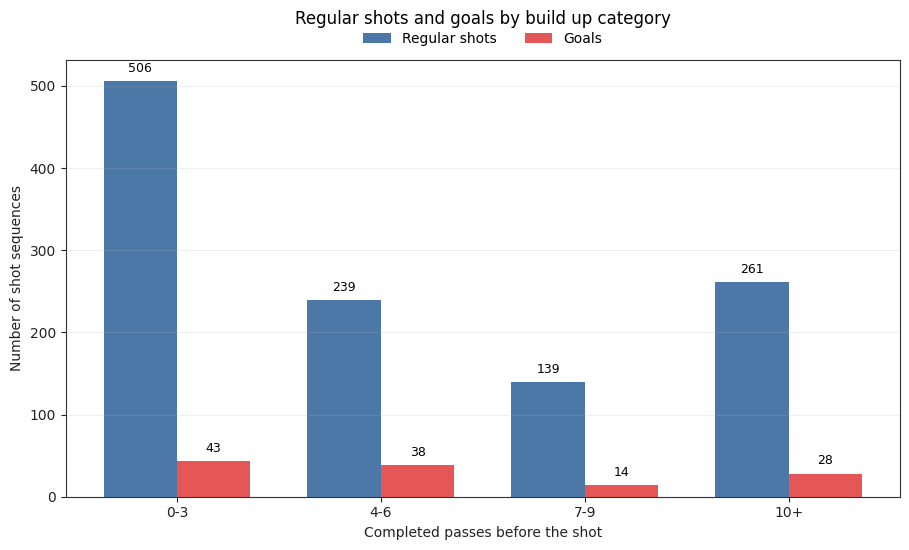

,shots,goals,average_xg,no_goal,conversion_rate
pass_category,,,,,
0-3,506,43,0.097962,463,0.084980
4-6,239,38,0.112189,201,0.158996
7-9,139,14,0.083633,125,0.100719
10+,261,28,0.102428,233,0.107280


In [13]:
category_summary = (
    shots_df
    .groupby("pass_category")
    .agg(
        shots=("pass_category", "count"),
        goals=("is_goal", "sum"),
        average_xg=("shot_xg", "mean")
    )
    .reindex(PASS_CATEGORY_ORDER)
    .fillna(0)
)

category_summary["no_goal"] = category_summary["shots"] - category_summary["goals"]
category_summary["conversion_rate"] = (
    category_summary["goals"] / category_summary["shots"].replace(0, np.nan)
)

fig, ax = plt.subplots(figsize=(9.2, 5.6))
x = np.arange(len(category_summary))
width = 0.36

shot_bars = ax.bar(
    x - width / 2,
    category_summary["shots"],
    width,
    label="Regular shots",
    color=COLORS["shot"]
)

goal_bars = ax.bar(
    x + width / 2,
    category_summary["goals"],
    width,
    label="Goals",
    color=COLORS["goal"]
)

for bars in [shot_bars, goal_bars]:
    for bar in bars:
        height = bar.get_height()
        label_height = height + max(category_summary["shots"].max() * 0.015, 1)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title("Regular shots and goals by build up category", pad=26)
ax.set_xlabel("Completed passes before the shot")
ax.set_ylabel("Number of shot sequences")
ax.set_xticks(x)
ax.set_xticklabels(category_summary.index)
legend_above(ax, ncol=2)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_build_up_volume_and_goals.png", dpi=300, bbox_inches="tight")
plt.show()

display(category_summary)


## 7. Build up efficiency

This plot compares goal conversion rate and average xG per shot.

Conversion rate shows how often shots became goals. Average xG shows the average chance quality. I use both measures in one plot because the pass categories are the same, but I do not compare the two axes directly.

This plot is descriptive. It does not prove that one build up category is always the best option.

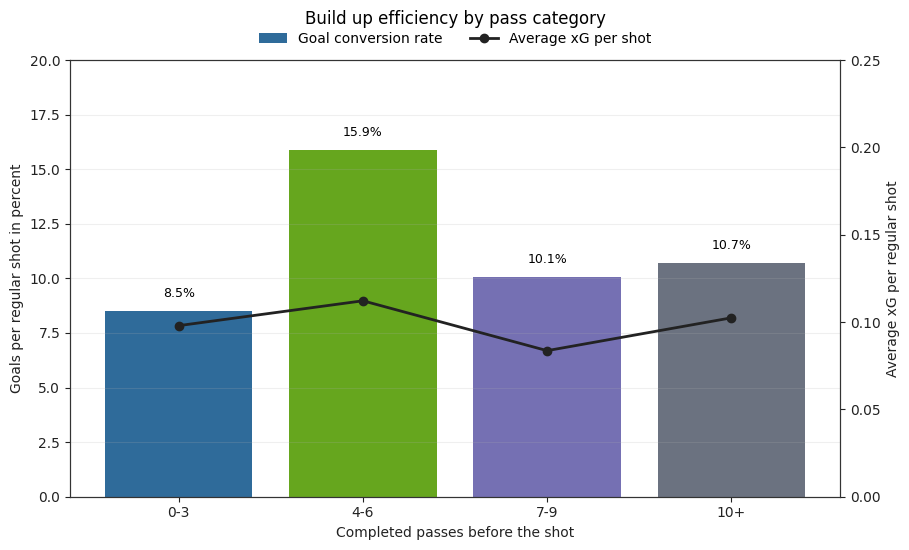

In [14]:
plot_data = category_summary.copy()

fig, ax1 = plt.subplots(figsize=(9.2, 5.6))

bar_colors = [
    PASS_CATEGORY_COLORS.get(str(category), "#6B7280")
    for category in plot_data.index
]

bars = ax1.bar(
    plot_data.index.astype(str),
    plot_data["conversion_rate"] * 100,
    color=bar_colors,
    label="Goal conversion rate"
)

ax1.set_title("Build up efficiency by pass category", pad=26)
ax1.set_xlabel("Completed passes before the shot")
ax1.set_ylabel("Goals per regular shot in percent")
ax1.set_ylim(0, max(20, plot_data["conversion_rate"].fillna(0).max() * 100 + 4))
ax1.grid(axis="y", alpha=0.2)

for bar, value in zip(bars, plot_data["conversion_rate"].fillna(0)):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax2 = ax1.twinx()
ax2.plot(
    plot_data.index.astype(str),
    plot_data["average_xg"],
    marker="o",
    linewidth=2,
    color=COLORS["dark"],
    label="Average xG per shot"
)

ax2.set_ylabel("Average xG per regular shot")
ax2.set_ylim(0, max(0.25, plot_data["average_xg"].fillna(0).max() + 0.05))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    borderaxespad=0.0
)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "02_build_up_efficiency_conversion_xg.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 8. Final third entries by team

This plot shows which teams often created shots after entering the final third.

For players and coaches, this is easier to understand than only looking at possession. The key question is whether the entry into a dangerous area also leads to a shot.

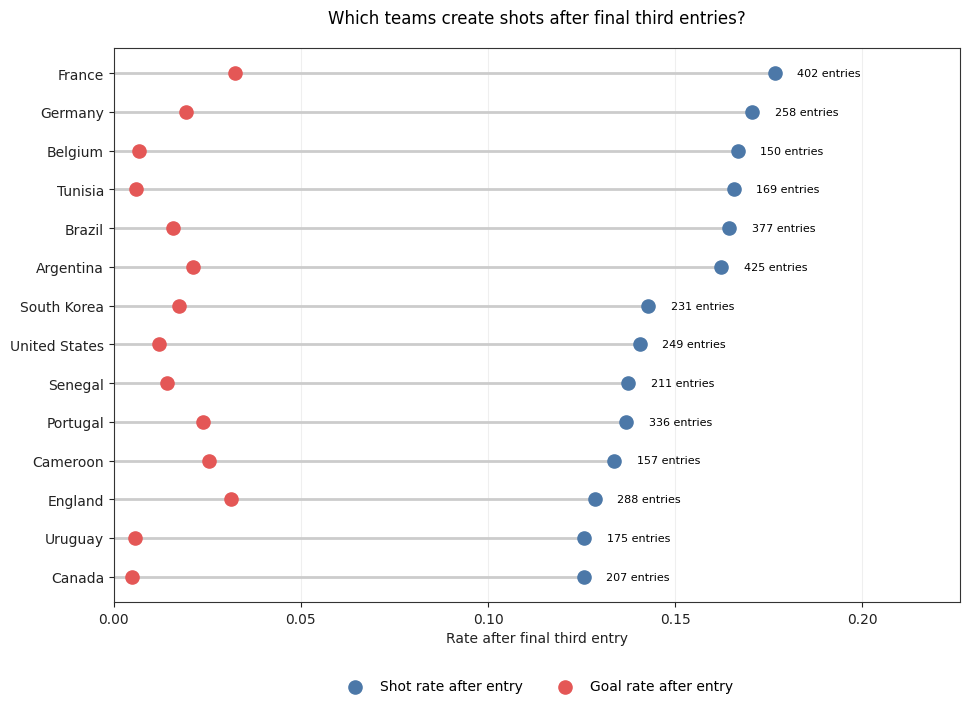

In [15]:
team_entry = team_summary[team_summary["entries"] >= 8].copy()

team_entry = (
    team_entry
    .sort_values("shot_rate_after_entry", ascending=True)
    .tail(14)
)

fig, ax = plt.subplots(figsize=(9.8, 7.2))
y = np.arange(len(team_entry))

ax.hlines(
    y,
    0,
    team_entry["shot_rate_after_entry"],
    color="#CCCCCC",
    linewidth=2
)

ax.scatter(
    team_entry["shot_rate_after_entry"],
    y,
    s=90,
    color=COLORS["shot"],
    label="Shot rate after entry",
    zorder=3
)

ax.scatter(
    team_entry["goal_rate_after_entry"],
    y,
    s=90,
    color=COLORS["goal"],
    label="Goal rate after entry",
    zorder=3
)

for i, row in enumerate(team_entry.itertuples()):
    ax.text(
        row.shot_rate_after_entry + 0.006,
        i,
        f"{row.entries:.0f} entries",
        va="center",
        fontsize=8
    )

ax.set_yticks(y)
ax.set_yticklabels(team_entry["team"])
ax.set_xlabel("Rate after final third entry")
ax.set_title("Which teams create shots after final third entries?", pad=18)
ax.set_xlim(0, max(team_entry["shot_rate_after_entry"].max() * 1.28, 0.1))

legend_below(ax, ncol=2)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "03_final_third_entry_outcomes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 9. Entry method and outcome

This plot compares how the ball entered the final third.

The word entry means that the ball is moved into the final third. This can happen through a long pass, a short pass, a carry or a possession that already starts high up the pitch.

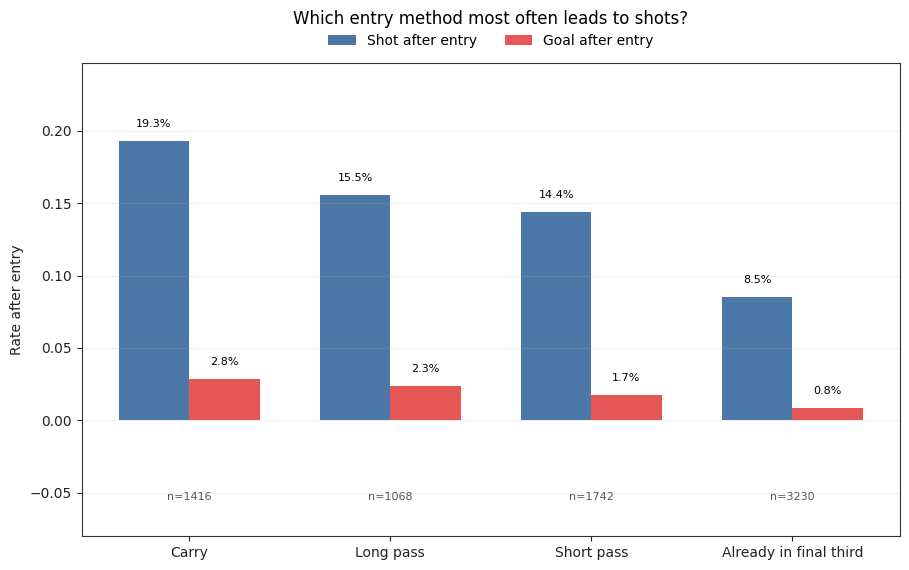

,entry_method,entries,shot_rate,goal_rate
1,Carry,1416,0.192797,0.028249
2,Long pass,1068,0.155431,0.023408
3,Short pass,1742,0.143513,0.017222
0,Already in final third,3230,0.084830,0.008359


In [16]:
method_summary = (
    entries_df
    .groupby("entry_method")
    .agg(
        entries=("entry_method", "count"),
        shot_rate=("shot_after_entry", "mean"),
        goal_rate=("goal_after_entry", "mean")
    )
    .reset_index()
)

method_summary = (
    method_summary[method_summary["entries"] >= 10]
    .sort_values("shot_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(9.2, 5.8))
x = np.arange(len(method_summary))
width = 0.35

ax.bar(
    x - width / 2,
    method_summary["shot_rate"],
    width,
    label="Shot after entry",
    color=COLORS["shot"]
)

ax.bar(
    x + width / 2,
    method_summary["goal_rate"],
    width,
    label="Goal after entry",
    color=COLORS["goal"]
)

for i, row in enumerate(method_summary.itertuples()):
    ax.text(i - width / 2, row.shot_rate + 0.01, percent_text(row.shot_rate), ha="center", fontsize=8)
    ax.text(i + width / 2, row.goal_rate + 0.01, percent_text(row.goal_rate), ha="center", fontsize=8)
    ax.text(i, -0.055, f"n={row.entries}", ha="center", fontsize=8, color="#555555")

ax.set_title("Which entry method most often leads to shots?", pad=28)
ax.set_ylabel("Rate after entry")
ax.set_xticks(x)
ax.set_xticklabels(method_summary["entry_method"], rotation=0)
ax.set_ylim(-0.08, max(method_summary["shot_rate"].max() * 1.28, 0.1))
legend_above(ax, ncol=2)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_entry_method_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

display(method_summary)


## 10. Start zone of goal attacks

This plot shows where goal attacks started.

The pitch is simplified into broad zones. This is less detailed than a heatmap, but easier to read for the target audience.

Because this plot only uses goals, some categories contain few examples. I use it as a simple overview, not as a strong statistical comparison.

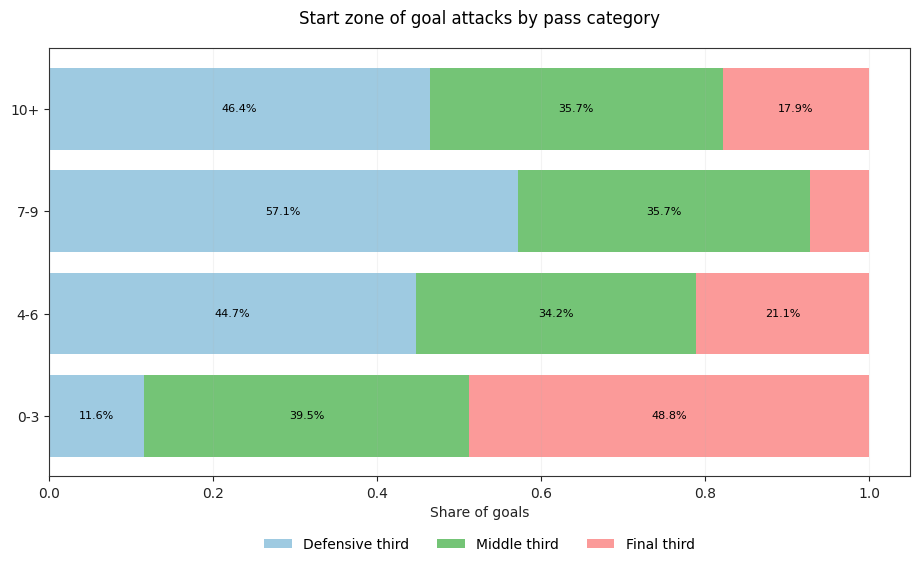

In [17]:
goals = shots_df[shots_df["is_goal"] == 1].copy()

start_matrix = (
    goals
    .groupby(["pass_category", "start_zone"])
    .size()
    .reset_index(name="count")
)

start_matrix["pass_category"] = pd.Categorical(
    start_matrix["pass_category"],
    categories=PASS_CATEGORY_ORDER,
    ordered=True
)

start_matrix = start_matrix.sort_values("pass_category")

pivot = start_matrix.pivot_table(
    index="pass_category",
    columns="start_zone",
    values="count",
    fill_value=0
)

zone_order = [
    "Defensive third",
    "Middle third",
    "Final third",
    "Unknown"
]

pivot = pivot.reindex(PASS_CATEGORY_ORDER).fillna(0)
pivot = pivot[[col for col in zone_order if col in pivot.columns]]
share = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9.3, 5.8))
left = np.zeros(len(share))

zone_colors = {
    "Defensive third": "#9ECAE1",
    "Middle third": "#74C476",
    "Final third": "#FB9A99",
    "Unknown": "#CCCCCC"
}

for zone in share.columns:
    ax.barh(
        share.index,
        share[zone],
        left=left,
        label=zone,
        color=zone_colors.get(zone, "#CCCCCC")
    )

    for i, value in enumerate(share[zone]):
        if value > 0.08:
            ax.text(
                left[i] + value / 2,
                i,
                percent_text(value),
                ha="center",
                va="center",
                fontsize=8
            )

    left += share[zone].values

ax.set_title("Start zone of goal attacks by pass category", pad=18)
ax.set_xlabel("Share of goals")
ax.set_ylabel("")

legend_below(ax, ncol=min(3, len(share.columns)))
ax.grid(axis="x", alpha=0.15)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "05_goal_start_zone.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 11. Team directness

This plot compares how many completed passes teams had before their goals.

Only teams with at least two analysed goals are shown. The plot should be read as a style indication, not as a stable ranking.

A direct team is not automatically better than a patient team.

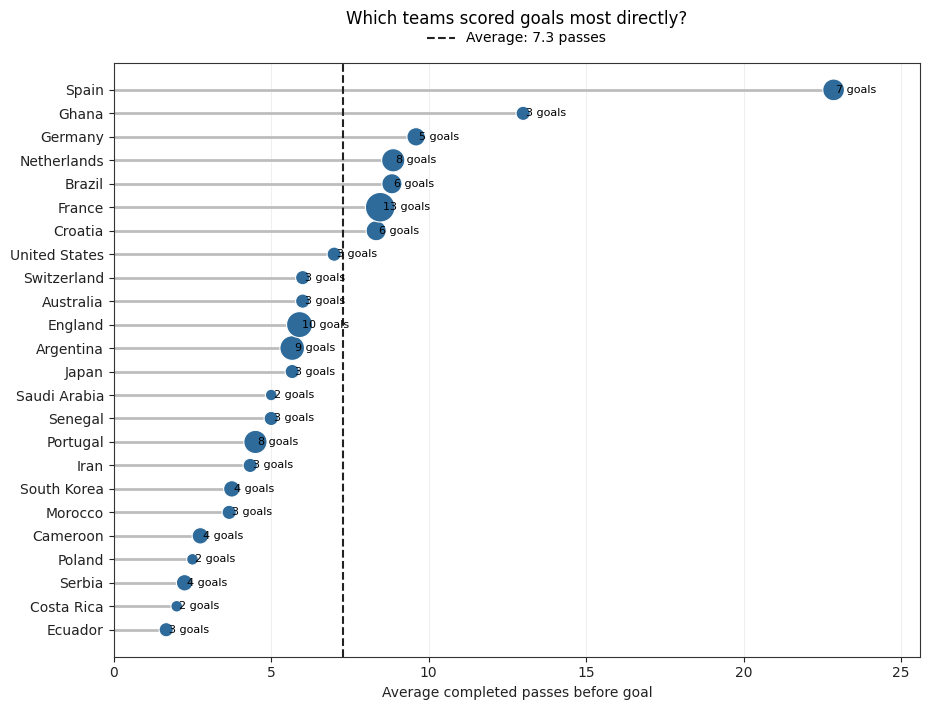

In [18]:
team_goals = (
    goals
    .groupby("team")
    .agg(
        goals=("is_goal", "sum"),
        avg_passes_before_goal=("passes_before_shot", "mean"),
        avg_duration=("duration_seconds", "mean")
    )
    .reset_index()
)

team_goals = (
    team_goals[team_goals["goals"] >= 2]
    .sort_values("avg_passes_before_goal", ascending=True)
)

fig, ax = plt.subplots(figsize=(9.4, 7.2))
y = np.arange(len(team_goals))

ax.hlines(
    y,
    0,
    team_goals["avg_passes_before_goal"],
    color="#BDBDBD",
    linewidth=2
)

ax.scatter(
    team_goals["avg_passes_before_goal"],
    y,
    s=team_goals["goals"] * 35,
    color=COLORS["direct"],
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

overall_avg = goals["passes_before_shot"].mean()

ax.axvline(
    overall_avg,
    color=COLORS["dark"],
    linestyle="--",
    linewidth=1.5,
    label=f"Average: {overall_avg:.1f} passes"
)

for i, row in enumerate(team_goals.itertuples()):
    ax.text(
        row.avg_passes_before_goal + 0.08,
        i,
        f"{row.goals:.0f} goals",
        va="center",
        fontsize=8
    )

ax.set_yticks(y)
ax.set_yticklabels(team_goals["team"])
ax.set_xlabel("Average completed passes before goal")
ax.set_title("Which teams scored goals most directly?", pad=28)
ax.set_xlim(
    0,
    max(
        team_goals["avg_passes_before_goal"].max() * 1.12,
        overall_avg * 1.4
    )
)

legend_above(ax, ncol=1)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "06_team_directness_ranking.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 12. Spain example

The Spain plot shows final third entries that led to shots.

This case study reloads only Spain matches because it is a separate detailed example. The same shot filter is applied again, so penalties and direct free kick shots are not counted here either.

The lines show the movement from entry to shot. The green areas show where Spain created chance quality. xG means expected goals and is used here as a simple measure of chance quality.

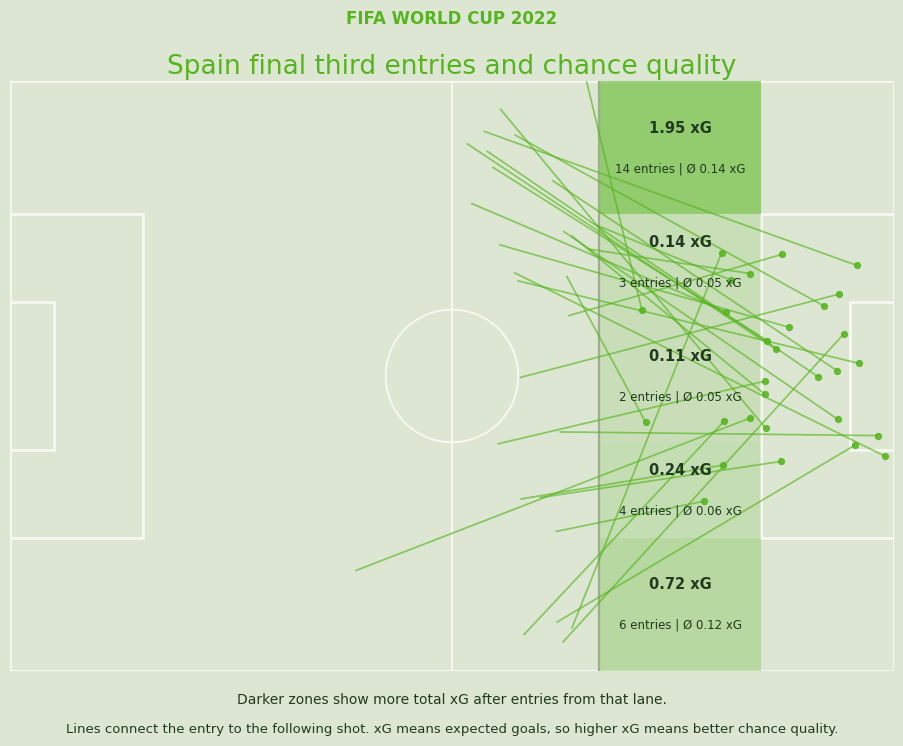

,entries,total_xg,avg_xg
lane,,,
Left wing,14,1.946669,0.139048
Left half space,3,0.143974,0.047991
Center,2,0.109851,0.054925
Right half space,4,0.236504,0.059126
Right wing,6,0.719170,0.119862


In [19]:
from matplotlib.patches import Rectangle, Arc
team_name = "Spain"
competition_id = 43
season_id = 106

matches = sb.matches(
    competition_id=competition_id,
    season_id=season_id
)

team_matches = matches[
    (matches["home_team"] == team_name)
    | (matches["away_team"] == team_name)
].copy()

def lane_name(y):
    if pd.isna(y):
        return np.nan
    if y < 18:
        return 'Left wing'
    if y < 31:
        return 'Left half space'
    if y < 49:
        return 'Center'
    if y < 62:
        return 'Right half space'
    return 'Right wing'
lane_order = [
    "Left wing",
    "Left half space",
    "Center",
    "Right half space",
    "Right wing"
]

lane_y = {
    "Left wing": (0, 18),
    "Left half space": (18, 31),
    "Center": (31, 49),
    "Right half space": (49, 62),
    "Right wing": (62, 80)
}

def collect_spain_entry_chances():
    rows = []
    for _, match in team_matches.iterrows():
        match_id = int(match['match_id'])
        events = sb.events(match_id=match_id)
        events = prepare_events(events).sort_values('index').copy()
        spain_events = events[events['team'] == team_name].copy()
        for possession_id, poss in spain_events.groupby('possession'):
            poss = poss.sort_values('index').copy()
            entries = poss[
                poss["type"].isin(["Pass", "Carry"])
                & poss["x"].notna()
                & poss["y"].notna()
                & poss["end_x"].notna()
                & poss["end_y"].notna()
                & (poss["x"] < 80)
                & (poss["end_x"] >= 80)
            ]
            if entries.empty:
                continue
            entry = entries.iloc[0]
            shots_after_entry = poss[
                (poss["type"] == "Shot")
                & (~poss["is_excluded_main_analysis_shot"])
                & poss["x"].notna()
                & poss["y"].notna()
                & (poss["index"] > entry["index"])
            ].copy()
            if shots_after_entry.empty:
                continue
            shot = shots_after_entry.iloc[0]
            shot_xg = shot.get('shot_xg', np.nan)
            if pd.isna(shot_xg):
                shot_xg = shot.get('shot_statsbomb_xg', np.nan)
            if pd.isna(shot_xg):
                shot_xg = 0.0
            rows.append(
                {
                    "match_id": match_id,
                    "possession": possession_id,
                    "entry_start_x": entry["x"],
                    "entry_start_y": entry["y"],
                    "entry_end_x": entry["end_x"],
                    "entry_end_y": entry["end_y"],
                    "shot_x": shot["x"],
                    "shot_y": shot["y"],
                    "shot_xg": float(shot_xg),
                    "lane": lane_name(entry["end_y"])
                }
            )
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.dropna(subset=['lane']).copy()
    return out
spain_entries = collect_spain_entry_chances()
if spain_entries.empty:
    raise ValueError('No Spain final third entries with a following shot were found.')
lane_summary = (
    spain_entries
    .groupby("lane")
    .agg(
        entries=("lane", "count"),
        total_xg=("shot_xg", "sum"),
        avg_xg=("shot_xg", "mean")
    )
    .reindex(lane_order)
    .fillna(0)
)

def draw_pitch(ax):
    bg = '#DDE6D2'
    line = '#F6F8F1'
    ax.set_facecolor(bg)
    ax.add_patch(Rectangle((0, 0), 120, 80, fill=False, edgecolor=line, linewidth=2))
    ax.plot([60, 60], [0, 80], color=line, linewidth=1.5)
    ax.add_patch(Arc((60, 40), 18, 18, theta1=0, theta2=360, color=line, linewidth=1.4))
    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, edgecolor=line, linewidth=2))
    ax.axvline(80, color='#9CAE8D', linewidth=1.6)
    ax.set_xlim(0, 120)
    ax.set_ylim(80, 0)
    ax.set_aspect('equal')
    ax.axis('off')
fig, ax = plt.subplots(figsize=(9.5, 7.2), facecolor='#DDE6D2')
draw_pitch(ax)
green = '#56B51F'
dark = '#203A1F'
max_xg = max(lane_summary['total_xg'].max(), 0.01)
for lane in lane_order:
    y0, y1 = lane_y[lane]
    total_xg = lane_summary.loc[lane, 'total_xg']
    entries = int(lane_summary.loc[lane, 'entries'])
    avg_xg = lane_summary.loc[lane, 'avg_xg']
    alpha = 0.12 + 0.43 * (total_xg / max_xg)
    ax.add_patch(Rectangle((80, y0), 22, y1 - y0, facecolor=green, edgecolor='none', alpha=alpha))
    y_mid = (y0 + y1) / 2
    ax.text(91, y_mid - 2.7, f'{total_xg:.2f} xG', ha='center', va='center', fontsize=10.5, color=dark, fontweight='bold')
    ax.text(91, y_mid + 2.8, f'{entries} entries | Ø {avg_xg:.2f} xG', ha='center', va='center', fontsize=8.5, color=dark)
for _, row in spain_entries.iterrows():
    ax.plot([row['entry_start_x'], row['shot_x']], [row['entry_start_y'], row['shot_y']], color=green, linewidth=1.25, alpha=0.65)
    ax.scatter(row['shot_x'], row['shot_y'], s=18, color=green, alpha=0.85)
ax.text(60, -8.5, 'FIFA WORLD CUP 2022', ha='center', va='center', fontsize=12, color=green, fontweight='bold')
ax.text(60, -2, 'Spain final third entries and chance quality', ha='center', va='center', fontsize=19, color=green)
ax.text(60, 84, 'Darker zones show more total xG after entries from that lane.', ha='center', va='center', fontsize=10, color=dark)
ax.text(60, 88, 'Lines connect the entry to the following shot. xG means expected goals, so higher xG means better chance quality.', ha='center', va='center', fontsize=9.5, color=dark)
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_spain_final_third_entries_for.png', dpi=300, bbox_inches='tight')
plt.show()
display(lane_summary)


## 13. Evaluation feedback

The evaluation was done with two teammates who play football. They understood the simple bar charts quickly. The difficult parts were the terms entry and xG, and the Spain plot because it contains several visual elements.

After the evaluation, I did not change the whole analysis. I mainly improved the wording around the plots. The feedback showed that the data story was understandable, but some terms needed clearer explanations.

The main changes were simpler explanations for entry and xG, stronger captions for the Spain plot and more careful wording around tactical interpretation.

## 14. Summary

The analysis does not show one perfect tactic. It shows simple patterns from World Cup data.

Main takeaways:

1. Many regular shots and goals happen after few passes.
2. The most common build up category is not automatically the most efficient one.
3. Entries into the final third are useful for studying attacking danger.
4. Directness describes style, not team quality.
5. The Spain plot shows how a possession based team created chances through repeated entry areas.

For amateur coaches, the results are best used as training ideas to improve game plan.

In [20]:
print('Final notebook check')
print('--------------------')
print(f'Regular shots analysed: {len(shots_df)}')
print(f"Goals analysed: {int(shots_df['is_goal'].sum())}")
print(f'Final third entries analysed: {len(entries_df)}')
print(f"Teams included: {shots_df['team'].nunique()}")
print('\nMain table used for build up interpretation:')
display(category_summary[['shots', 'goals', 'conversion_rate', 'average_xg']])
print('\nFigures saved in:')
print(FIGURE_DIR)


Final notebook check
--------------------
Regular shots analysed: 1145
Goals analysed: 123
Final third entries analysed: 7456
Teams included: 32

Main table used for build up interpretation:


,shots,goals,conversion_rate,average_xg
pass_category,,,,
0-3,506,43,0.084980,0.097962
4-6,239,38,0.158996,0.112189
7-9,139,14,0.100719,0.083633
10+,261,28,0.107280,0.102428



Figures saved in:
c:\Users\tezca\Football\GDV\figures
